In [6]:
#Q1) a)
import glob
import os
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets,transforms
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import random_split

class MyDataset(Dataset):
    def __init__(self,transform=transforms,split="train"):
        self.imgs_path = os.path.join("data", "cats_and_dogs_filtered", split)
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        print(class_folders)
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])
        
        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]
        if (self.transform):
            img=self.transform(img)
        return img,label

preprocess=transforms.Compose([transforms.Resize((128,128)),
                               transforms.ToTensor(),
                               transforms.Normalize(
                                   mean=[0.485,0.456,0.406],
                                   std=[0.229,0.224,0.225]
                               ),])
torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)
dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])
print(len(train_dataset))

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=0.0001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        #print(labels)
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    

Device:  cuda
['data/cats_set', 'data/dogs_set']
800
Epoch [1/10], Loss: 0.8428
Validation Accuracy: 58.00%
Epoch [2/10], Loss: 0.6994
Validation Accuracy: 56.00%
Epoch [3/10], Loss: 0.6657
Validation Accuracy: 57.50%
Epoch [4/10], Loss: 0.6321
Validation Accuracy: 64.00%
Epoch [5/10], Loss: 0.5747
Validation Accuracy: 66.00%
Epoch [6/10], Loss: 0.5043
Validation Accuracy: 64.00%
Epoch [7/10], Loss: 0.4349
Validation Accuracy: 63.00%
Epoch [8/10], Loss: 0.3529
Validation Accuracy: 61.50%
Epoch [9/10], Loss: 0.2507
Validation Accuracy: 66.50%
Epoch [10/10], Loss: 0.1928
Validation Accuracy: 64.50%


In [7]:
#Q1 -b
import glob
import os
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets,transforms
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import random_split

class MyDataset(Dataset):
    def __init__(self,transform=transforms,split="train"):
        self.imgs_path = os.path.join("data", "cats_and_dogs_filtered", split)
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        print(class_folders)
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])
        
        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]
        if (self.transform):
            img=self.transform(img)
        return img,label

preprocess=transforms.Compose([transforms.Resize((128,128)),
                               transforms.ToTensor(),
                               transforms.Normalize(
                                   mean=[0.485,0.456,0.406],
                                   std=[0.229,0.224,0.225]
                               ),])
torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)
dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            #nn.Dropout(0.5),
            nn.Linear(256, 2)  # 2 classes: cat, dog
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = CNN().to(device)

#Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Training Loop
epochs = 10
lambda_l2=1e-4

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        #print(labels)
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        l2_norm=0
        for param in model.parameters():
            l2_norm+=torch.norm(param,2)**2
        loss+=lambda_l2*l2_norm
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    

Device:  cuda
['data/cats_set', 'data/dogs_set']
Epoch [1/10], Loss: 0.8620
Validation Accuracy: 57.50%
Epoch [2/10], Loss: 0.7240
Validation Accuracy: 57.00%
Epoch [3/10], Loss: 0.6894
Validation Accuracy: 59.00%
Epoch [4/10], Loss: 0.6487
Validation Accuracy: 68.00%
Epoch [5/10], Loss: 0.5819
Validation Accuracy: 68.00%
Epoch [6/10], Loss: 0.5225
Validation Accuracy: 63.50%
Epoch [7/10], Loss: 0.4553
Validation Accuracy: 62.50%
Epoch [8/10], Loss: 0.3701
Validation Accuracy: 62.50%
Epoch [9/10], Loss: 0.2567
Validation Accuracy: 63.50%
Epoch [10/10], Loss: 0.2071
Validation Accuracy: 60.50%


In [8]:
#Q2-a-same as Q1 a
#weight decay cant be added for l1--> l2-->Q1)a

In [9]:
#Q2 -b

import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import random_split

class MyDataset(Dataset):
    def __init__(self,transform=transforms,split="train"):
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        print(class_folders)
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            print(class_name)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])
        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self,idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]
        if (self.transform):
            img=self.transform(img)
        return img,label
    
preprocess=transforms.Compose([transforms.Resize((128,128)),
                               transforms.ToTensor(),
                               transforms.Normalize(
                                           mean=[0.485, 0.456, 0.406],
                                           std=[0.229, 0.224, 0.225]),
                               ])

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Linear(256,2) #since 2 classs-cat n dog
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x

model=CNN().to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

epochs=10
lambda_l1=1e-5

def compute_l1_norm(model):
    total=0
    for param in model.parameters():
        total+=torch.sum(torch.abs(param))
    return total

for epoch in range(epochs):
    model.train()
    running_loss=0
    for images, labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        l1_norm=compute_l1_norm(model)
        loss=loss+lambda_l1*l1_norm

        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Training Loss: {running_loss/len(train_loader):.4f}")

    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    accuracy=100*correct/total
    print(f"Validation Accuracy: {accuracy:.2f}%")

    print(f"L1 Weight Norm: {compute_l1_norm(model):.4f}")

Device:  cuda
['data/cats_set', 'data/dogs_set']
cats_set
dogs_set

Epoch [1/10]
Training Loss: 1.0507
Validation Accuracy: 48.00%
L1 Weight Norm: 19113.5215

Epoch [2/10]
Training Loss: 0.8622
Validation Accuracy: 65.00%
L1 Weight Norm: 13885.6045

Epoch [3/10]
Training Loss: 0.7994
Validation Accuracy: 57.50%
L1 Weight Norm: 10392.6895

Epoch [4/10]
Training Loss: 0.7656
Validation Accuracy: 62.00%
L1 Weight Norm: 8477.5029

Epoch [5/10]
Training Loss: 0.7003
Validation Accuracy: 65.00%
L1 Weight Norm: 7596.4375

Epoch [6/10]
Training Loss: 0.6374
Validation Accuracy: 65.00%
L1 Weight Norm: 7263.2690

Epoch [7/10]
Training Loss: 0.5711
Validation Accuracy: 63.50%
L1 Weight Norm: 7251.6460

Epoch [8/10]
Training Loss: 0.4723
Validation Accuracy: 64.00%
L1 Weight Norm: 7393.8872

Epoch [9/10]
Training Loss: 0.4097
Validation Accuracy: 67.00%
L1 Weight Norm: 7865.2437

Epoch [10/10]
Training Loss: 0.3678
Validation Accuracy: 63.00%
L1 Weight Norm: 8213.8057


In [10]:
#code to compute the mean n std in Normalize transofrm

from torchvision import datasets, transforms
import torch

# 1. Resize + convert to tensor
to_tensor = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize all images to 128x128
    transforms.ToTensor()
])

# 2. Load dataset
dataset = datasets.ImageFolder("data", transform=to_tensor)

# 3. Stack all images into one tensor
all_imgs = torch.stack([img for img, _ in dataset], dim=0)

# 4. Compute mean and std per channel
mean = all_imgs.mean(dim=(0, 2, 3))
std = all_imgs.std(dim=(0, 2, 3))

print(mean, std)

tensor([0.4884, 0.4553, 0.4161]) tensor([0.2553, 0.2485, 0.2527])


### Lab7 - continued- 24/03/2026

Device:  cuda

 Without Dropout
Epoch: 1/10, Train Loss: 0.8438, Validation Accuracy: 58.50%
Epoch: 2/10, Train Loss: 0.6988, Validation Accuracy: 55.00%
Epoch: 3/10, Train Loss: 0.6644, Validation Accuracy: 64.50%
Epoch: 4/10, Train Loss: 0.6225, Validation Accuracy: 63.00%
Epoch: 5/10, Train Loss: 0.5651, Validation Accuracy: 60.00%
Epoch: 6/10, Train Loss: 0.5095, Validation Accuracy: 61.00%
Epoch: 7/10, Train Loss: 0.4180, Validation Accuracy: 59.00%
Epoch: 8/10, Train Loss: 0.3183, Validation Accuracy: 61.50%
Epoch: 9/10, Train Loss: 0.1952, Validation Accuracy: 64.00%
Epoch: 10/10, Train Loss: 0.1700, Validation Accuracy: 61.00%

 With Dropout
Epoch: 1/10, Train Loss: 0.8466, Validation Accuracy: 43.50%
Epoch: 2/10, Train Loss: 0.6938, Validation Accuracy: 61.50%
Epoch: 3/10, Train Loss: 0.6827, Validation Accuracy: 44.00%
Epoch: 4/10, Train Loss: 0.6765, Validation Accuracy: 66.50%
Epoch: 5/10, Train Loss: 0.6396, Validation Accuracy: 68.00%
Epoch: 6/10, Train Loss: 0.6176, Vali

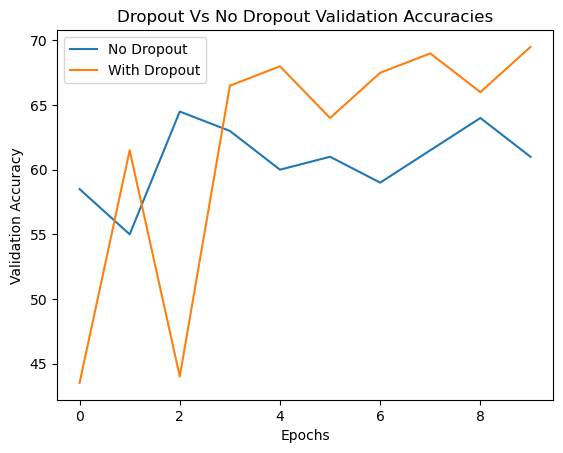

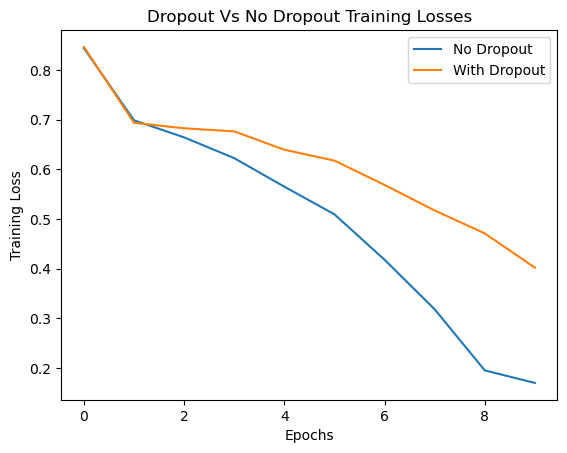

In [ ]:
#Q3)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from PIL import Image

class MyDataset(Dataset):
    def __init__(self,transform=None):
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])

        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]

        if self.transform:
            img=self.transform(img)
        return img,label

preprocess=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),#(50,3,128,128)-->(50,32,64,64)

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),#(50,32,64,64)-->(50,64,32,32)

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),#(50,64,32,32)-->(50,128,16,16)

        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x
    
class CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x

def train_model(model,name,epochs=10):
    print("\n",name)
    model=model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(), lr=0.001)

    train_loss_list=[]
    val_acc=[]

    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for images,labels in train_loader:
            images,labels=images.to(device),labels.to(device)

            outputs=model(images)
            loss=criterion(outputs,labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()
        avg_loss=running_loss/len(train_loader)
        train_loss_list.append(avg_loss)

        model.eval()
        correct=0
        total=0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                
                _,pred=torch.max(outputs,1)
                
                total+=labels.size(0)
                correct+=(pred==labels).sum().item()
        acc=100*(correct/total)
        val_acc.append(acc)

        print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Validation Accuracy: {acc:.2f}%")
    
    return train_loss_list,val_acc

train_loss, val_acc=train_model(CNN(),"Without Dropout")
loss_dropout, acc_dropout=train_model(CNN_Dropout(),"With Dropout")

print("\nComparing Dropout and Without Drouput")
print(f"Without Dropout Accuracy: {val_acc[-1]:.2f}%")
print(f"With Dropout Accuracy: {acc_dropout[-1]:.2f}%")

plt.plot(val_acc,label="No Dropout")
plt.plot(acc_dropout,label="With Dropout")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Dropout Vs No Dropout Validation Accuracies")
plt.show()


plt.plot(train_loss,label="No Dropout")
plt.plot(loss_dropout,label="With Dropout")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.title("Dropout Vs No Dropout Training Losses")
plt.show()

Device:  cuda

 Custom Dropout
Epoch: 1/10, Train Loss: 1.0177, Validation Accuracy: 49.00%
Epoch: 2/10, Train Loss: 0.6996, Validation Accuracy: 57.00%
Epoch: 3/10, Train Loss: 0.6860, Validation Accuracy: 65.50%
Epoch: 4/10, Train Loss: 0.6839, Validation Accuracy: 62.50%
Epoch: 5/10, Train Loss: 0.6786, Validation Accuracy: 57.50%
Epoch: 6/10, Train Loss: 0.6683, Validation Accuracy: 54.00%
Epoch: 7/10, Train Loss: 0.6191, Validation Accuracy: 63.50%
Epoch: 8/10, Train Loss: 0.5563, Validation Accuracy: 58.00%
Epoch: 9/10, Train Loss: 0.4876, Validation Accuracy: 61.00%
Epoch: 10/10, Train Loss: 0.3988, Validation Accuracy: 56.50%

 Pytorch Dropout
Epoch: 1/10, Train Loss: 0.7351, Validation Accuracy: 43.50%
Epoch: 2/10, Train Loss: 0.6929, Validation Accuracy: 51.50%
Epoch: 3/10, Train Loss: 0.6918, Validation Accuracy: 63.50%
Epoch: 4/10, Train Loss: 0.6830, Validation Accuracy: 57.00%
Epoch: 5/10, Train Loss: 0.6431, Validation Accuracy: 64.00%
Epoch: 6/10, Train Loss: 0.6105, Va

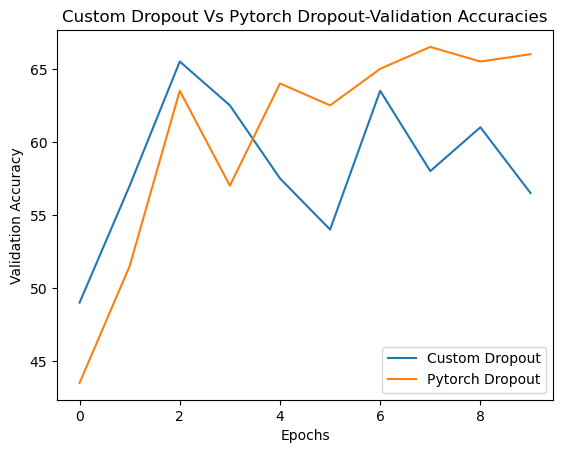

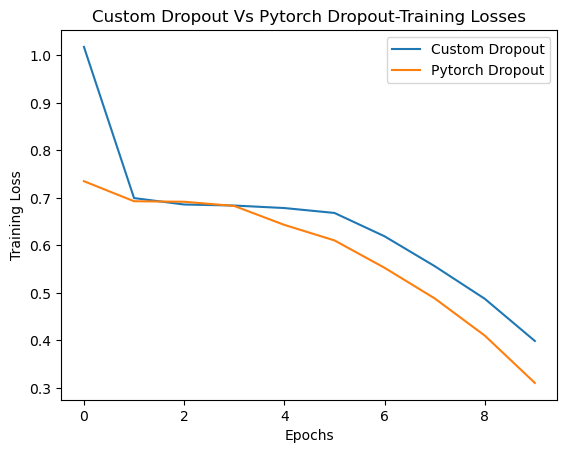

In [ ]:
#Q4)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from PIL import Image

class MyDataset(Dataset):
    def __init__(self,transform=None):
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])

        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]

        if self.transform:
            img=self.transform(img)
        return img,label

preprocess=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)


class CustomDropout(nn.Module):
    def __init__(self,p=0.5):
        super().__init__()
        self.p=p
    def forward(self,x):
        if (self.training):
            mask=torch.bernoulli(torch.ones_like(x)*(1-self.p)).to(x.device)
            return x*mask/(1-self.p)
        else:
            return x

class CNN_CustomDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),#(50,3,128,128)-->(50,32,64,64)

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),#(50,32,64,64)-->(50,64,32,32)

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            CustomDropout(p=0.5),
            nn.MaxPool2d(2),#(50,64,32,32)-->(50,128,16,16)

        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x
    
class CNN_PytorchDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x

def train_model(model,name,epochs=10):
    print("\n",name)
    model=model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(), lr=0.001)

    train_loss_list=[]
    val_acc=[]

    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for images,labels in train_loader:
            images,labels=images.to(device),labels.to(device)

            outputs=model(images)
            loss=criterion(outputs,labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()
        avg_loss=running_loss/len(train_loader)
        train_loss_list.append(avg_loss)

        model.eval()
        correct=0
        total=0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                
                _,pred=torch.max(outputs,1)
                
                total+=labels.size(0)
                correct+=(pred==labels).sum().item()
        acc=100*(correct/total)
        val_acc.append(acc)

        print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Validation Accuracy: {acc:.2f}%")
    
    return train_loss_list,val_acc

train_loss_cust, val_acc_cust=train_model(CNN_CustomDrop(),"Custom Dropout")
train_loss_py, val_acc_py=train_model(CNN_PytorchDrop(),"Pytorch Dropout")

print("\nComparing Custom Vs Pytorch Dropout")
print(f"Custom Dropout Accuracy: {val_acc_cust[-1]:.2f}%")
print(f"Pytorch Dropout Accuracy: {val_acc_py[-1]:.2f}%")

plt.plot(val_acc_cust,label="Custom Dropout")
plt.plot(val_acc_py,label="Pytorch Dropout")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Custom Dropout Vs Pytorch Dropout-Validation Accuracies")
plt.show()


plt.plot(train_loss_cust,label="Custom Dropout")
plt.plot(train_loss_py,label="Pytorch Dropout")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.title("Custom Dropout Vs Pytorch Dropout-Training Losses")
plt.show()

Device:  cuda

 CNN With Early Stopping
Epoch: 1/30, Train Loss: 0.8438, Validation Loss: 0.6734, Validation Accuracy: 58.50%
Epoch: 2/30, Train Loss: 0.6969, Validation Loss: 0.6762, Validation Accuracy: 56.50%
Epoch: 3/30, Train Loss: 0.6637, Validation Loss: 0.6470, Validation Accuracy: 64.00%
Epoch: 4/30, Train Loss: 0.6209, Validation Loss: 0.6513, Validation Accuracy: 61.00%
Epoch: 5/30, Train Loss: 0.5652, Validation Loss: 0.7075, Validation Accuracy: 56.00%
Epoch: 6/30, Train Loss: 0.4948, Validation Loss: 0.7167, Validation Accuracy: 60.00%
Epoch: 7/30, Train Loss: 0.3943, Validation Loss: 0.7527, Validation Accuracy: 62.50%
Epoch: 8/30, Train Loss: 0.2959, Validation Loss: 0.8202, Validation Accuracy: 62.50%
Early stopping at epoch: 8, Patience: 5

 CNN Without Early Stopping
Epoch: 1/30, Train Loss: 0.8403, Validation Loss: 0.6957, Validation Accuracy: 43.50%
Epoch: 2/30, Train Loss: 0.6893, Validation Loss: 0.6673, Validation Accuracy: 61.00%
Epoch: 3/30, Train Loss: 0.6806

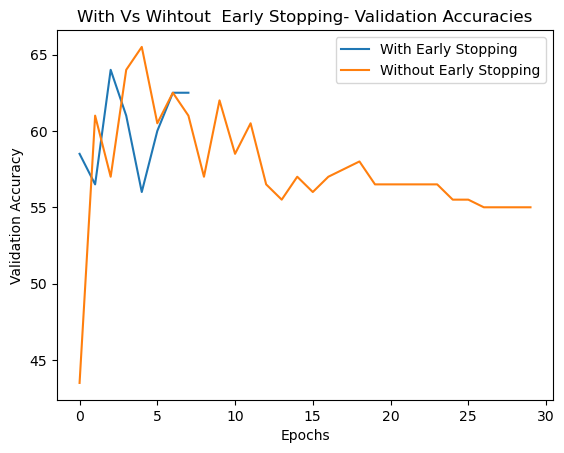

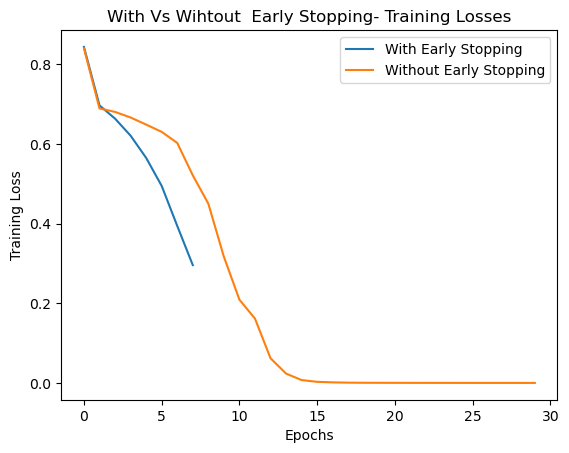

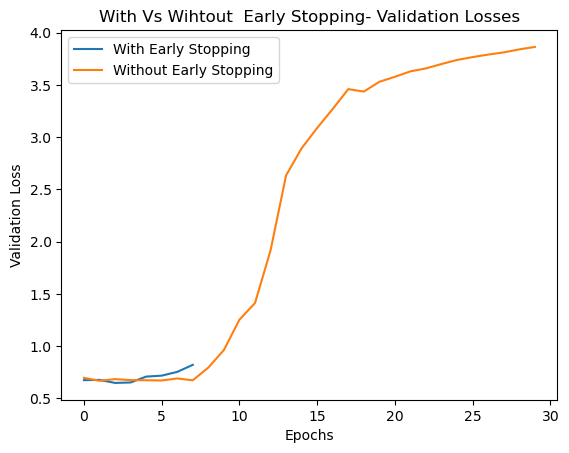

In [ ]:
#q5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from PIL import Image

class MyDataset(Dataset):
    def __init__(self,transform=None):
        self.data=[]
        class_folders=glob.glob(os.path.join("data","*"))
        for class_path in class_folders:
            class_name=os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path,"*.jpg")):
                self.data.append([img_path,class_name])

        self.class_map={"dogs_set":0,"cats_set":1}
        self.transform=transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path,class_name=self.data[idx]
        img=Image.open(img_path).convert("RGB")
        label=self.class_map[class_name]

        if self.transform:
            img=self.transform(img)
        return img,label

preprocess=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

torch.manual_seed(42)
np.random.seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

dataset=MyDataset(transform=preprocess)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=50,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=50,shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc=nn.Sequential(
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x=self.conv(x)
        x=torch.flatten(x,1)
        x=self.fc(x)
        return x

def train_model_early_stopping(model,name,epochs=20,patience=3,early_stop=False):
    print("\n",name)
    model=model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(), lr=0.001)

    best_val_loss=float('inf')
    curr_patience=0

    train_loss_list=[]
    val_acc=[]
    val_loss_list=[]

    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for images,labels in train_loader:
            images,labels=images.to(device),labels.to(device)

            outputs=model(images)
            loss=criterion(outputs,labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()
        avg_loss=running_loss/len(train_loader)
        train_loss_list.append(avg_loss)

        model.eval()
        correct=0
        total=0
        val_loss=0.0

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                loss=criterion(outputs,labels)
                val_loss+=loss.item()

                _,pred=torch.max(outputs,1)
                
                total+=labels.size(0)
                correct+=(pred==labels).sum().item()
        avg_val_loss=val_loss/len(val_loader)
        val_loss_list.append(avg_val_loss)
        acc=100*(correct/total)
        val_acc.append(acc)

        print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {acc:.2f}%")

        if (early_stop==True):
            if (avg_val_loss<best_val_loss):
                best_val_loss=avg_val_loss
                curr_patience=0
                torch.save(model.state_dict(),"best_model.pth")
            else:
                curr_patience+=1
                if (curr_patience>=patience):
                    print(f"Early stopping at epoch: {epoch+1}, Patience: {patience}")
                    break
    model.load_state_dict(torch.load('best_model.pth'))
    return train_loss_list,val_loss_list,val_acc

train_loss_es, val_loss_es, val_acc_es=train_model_early_stopping(CNN(),"CNN With Early Stopping",epochs=30,patience=5,early_stop=True)
train_loss, val_loss, val_acc=train_model_early_stopping(CNN(),"CNN Without Early Stopping",epochs=30,patience=5,early_stop=False)

print("\nComparing Early Stopping Vs Wihout Early Stopping")
print(f"With Early Stopping Accuracy: {val_acc_es[-1]:.2f}%")
print(f"Without Early Stopping Accuracy: {val_acc[-1]:.2f}%")

plt.plot(val_acc_es,label="With Early Stopping")
plt.plot(val_acc,label="Without Early Stopping")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("With Vs Wihtout  Early Stopping- Validation Accuracies")
plt.show()

plt.plot(train_loss_es,label="With Early Stopping")
plt.plot(train_loss,label="Without Early Stopping")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.title("With Vs Wihtout  Early Stopping- Training Losses")
plt.show()

plt.plot(val_loss_es,label="With Early Stopping")
plt.plot(val_loss,label="Without Early Stopping")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("With Vs Wihtout  Early Stopping- Validation Losses")
plt.show()


### LAB 8- RNN- Q1

Data:
            Date  Price
0     1997-01-07   3.82
1     1997-01-08   3.80
2     1997-01-09   3.61
3     1997-01-10   3.92
4     1997-01-13   4.00
...          ...    ...
5948  2020-08-26   2.52
5949  2020-08-27   2.52
5950  2020-08-28   2.46
5951  2020-08-31   2.30
5952  2020-09-01   2.22

[5953 rows x 2 columns]
Length of Data: 5953
Length of Data after dropping null: 5952

Length of y:  5952
Minimum val: 1.05,Maximum value: 18.48
0 th iteration :  tensor(0.1808, grad_fn=<MseLossBackward0>)
50 th iteration :  tensor(0.0352, grad_fn=<MseLossBackward0>)
100 th iteration :  tensor(0.0148, grad_fn=<MseLossBackward0>)
150 th iteration :  tensor(0.0200, grad_fn=<MseLossBackward0>)
200 th iteration :  tensor(0.0157, grad_fn=<MseLossBackward0>)
250 th iteration :  tensor(0.0205, grad_fn=<MseLossBackward0>)
300 th iteration :  tensor(0.0157, grad_fn=<MseLossBackward0>)
350 th iteration :  tensor(0.0154, grad_fn=<MseLossBackward0>)
400 th iteration :  tensor(0.0171, grad_fn=<MseLossBackward

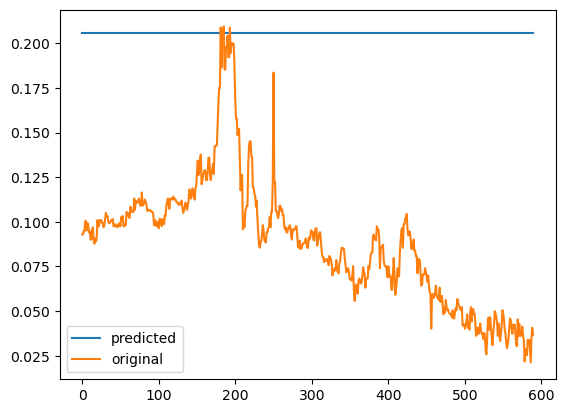

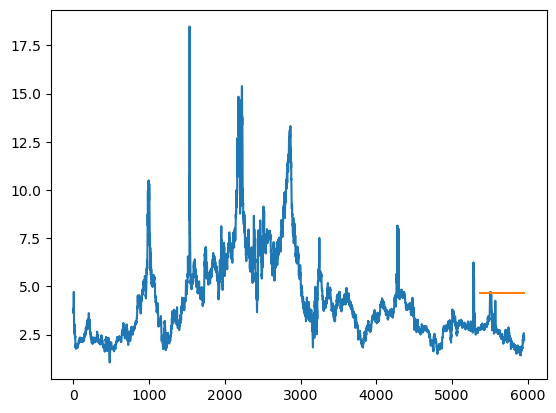

In [ ]:
#Q)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df=pd.read_csv("./natural_gas_data/natural-gas_zip/archive/daily.csv")
print("Data:")
print(df)
print("Length of Data:",len(df))

df=df.dropna()
print("Length of Data after dropping null:",len(df))

y=df["Price"].values
x=np.arange(1,len(y))

print("\nLength of y: ",len(y))

minm=y.min()
maxm=y.max()
print(f"Minimum val: {minm},Maximum value: {maxm}")

y=(y-minm)/(maxm-minm) #normalize the ip range

Sequence_length=10

X=[]
Y=[]
for i in range(len(y) - Sequence_length):
    list1=[]
    for j in range(i,i+Sequence_length):
        list1.append(y[j])
    X.append(list1)
    Y.append(y[j+1])

X=np.array(X)
Y=np.array(Y)

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.10,random_state=42,
                                               shuffle=False,stratify=None)

class NGTimeSeries(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
        self.len=x.shape[0]
    def __getitem__(self, idx):
        return self.x[idx],self.y[idx]
    def __len__(self):
        return self.len

dataset=NGTimeSeries(x_train,y_train)

train_loader=DataLoader(dataset,batch_size=256,shuffle=True)

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn=nn.RNN(input_size=1,hidden_size=5,num_layers=1,batch_first=True)
        self.fc1=nn.Linear(in_features=5,out_features=1)
    def forward(self, x):
        output, _ = self.rnn(x)        
        output = output[:, -1, :]            
        output = self.fc1(torch.relu(output))
        return output

model = RNNModel()

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
epochs = 1500

for i in range(epochs):
    for j, data in enumerate(train_loader):
        y_pred = model(data[0].view(-1, Sequence_length, 1)).reshape(-1)
        loss = criterion(y_pred, data[:][1])
        loss.backward()
        optimizer.step()
    if i % 50 == 0:
        print(i, "th iteration : ", loss)

test_set = NGTimeSeries(x_test,y_test)
test_pred = model(test_set[:][0].view(-1,10,1)).view(-1)
plt.plot(test_pred.detach().numpy(),label='predicted')
plt.plot(test_set[:][1].view(-1),label='original')
plt.legend()
plt.show()

y = y * (maxm - minm) + minm
y_pred = test_pred.detach().numpy() * (maxm - minm) + minm
plt.plot(y)
plt.plot(range(len(y)-len(y_pred), len(y)), y_pred)
plt.show()



In [ ]:
#WHOLE CODE- EASIER VERSION

# importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("./natural_gas_data/natural-gas_zip/archive/daily.csv")

print("Length of Data:", len(df))

# Drop missing values
df = df.dropna()
print("Length after dropping NA:", len(df))

# Extract price column
y = df["Price"].values

# Normalize data
minm = y.min()
maxm = y.max()
y = (y - minm) / (maxm - minm)

# Sequence length
Sequence_length = 10

# Create sequences
X = []
Y = []

for i in range(len(y) - Sequence_length - 1):
    seq = []
    for j in range(i, i + Sequence_length):
        seq.append(y[j])
    X.append(seq)
    Y.append(y[j + 1])

X = np.array(X)
Y = np.array(Y)

# Train-test split (NO shuffle for time series)
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.10, shuffle=False
)

# Dataset class
class NGTimeSeries(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# DataLoader
train_dataset = NGTimeSeries(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# RNN Model
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=5, num_layers=1, batch_first=True)
        self.fc = nn.Linear(5, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]          # last time step
        out = self.fc(torch.relu(out))
        return out

# Initialize model
model = RNNModel()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 1500

# Training loop
for epoch in range(epochs):
    for inputs, targets in train_loader:

        optimizer.zero_grad()

        inputs = inputs.view(-1, Sequence_length, 1)

        outputs = model(inputs).squeeze()

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Testing
model.eval()

test_inputs = torch.tensor(x_test, dtype=torch.float32).view(-1, Sequence_length, 1)
test_targets = torch.tensor(y_test, dtype=torch.float32)

with torch.no_grad():
    test_pred = model(test_inputs).squeeze().numpy()

# Plot predicted vs actual (normalized)
plt.plot(test_pred, label="Predicted")
plt.plot(test_targets.numpy(), label="Actual")
plt.legend()
plt.title("Normalized Prediction")
plt.show()

# Denormalize
y_actual = y * (maxm - minm) + minm
y_pred = test_pred * (maxm - minm) + minm

# Plot full series + predictions
plt.plot(y_actual, label="Actual Data")
plt.plot(range(len(y_actual)-len(y_pred), len(y_actual)), y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()